In [45]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [46]:

stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS']
data=yf.download(stocks,start='2023-01-01',end='2023-12-31')['Close']



[*********************100%***********************]  5 of 5 completed


In [47]:
daily_return=data.pct_change().dropna()


In [48]:
annaulized_return=daily_return.mean()*252
annaulized_risk=daily_return.std()*np.sqrt(252)
cov_matrix=daily_return.cov()*252
print("Annualized Returns:")
print(annaulized_return)
print("\nAnnualized Volatility:")
print(annaulized_risk)
print("\nAnnualized Covariance Matrix:")
print(cov_matrix)

Annualized Returns:
Ticker
HDFCBANK.NS     0.075879
ICICIBANK.NS    0.122985
INFY.NS         0.067288
RELIANCE.NS     0.105092
TCS.NS          0.208700
dtype: float64

Annualized Volatility:
Ticker
HDFCBANK.NS     0.168585
ICICIBANK.NS    0.155332
INFY.NS         0.233280
RELIANCE.NS     0.174187
TCS.NS          0.181844
dtype: float64

Annualized Covariance Matrix:
Ticker        HDFCBANK.NS  ICICIBANK.NS   INFY.NS  RELIANCE.NS    TCS.NS
Ticker                                                                  
HDFCBANK.NS      0.028421      0.011355  0.010892     0.011544  0.007318
ICICIBANK.NS     0.011355      0.024128  0.008513     0.011392  0.005378
INFY.NS          0.010892      0.008513  0.054419     0.012951  0.029240
RELIANCE.NS      0.011544      0.011392  0.012951     0.030341  0.006914
TCS.NS           0.007318      0.005378  0.029240     0.006914  0.033067


In [49]:
import numpy as np
num_portfolios = 10000
risk_free_rate = 0.05

portfolio_returns = []
portfolio_risks = []
portfolio_sharpes = []
portfolio_weights = []

for _ in range(num_portfolios):

    weights = np.random.random(len(stocks))
    weights = weights / np.sum(weights)

    port_return = np.sum(weights * annaulized_return)

    port_risk = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    sharpe = (port_return - risk_free_rate) / port_risk
    portfolio_returns.append(port_return)   
    portfolio_risks.append(port_risk)       
    portfolio_sharpes.append(sharpe)
    portfolio_weights.append(weights)





In [50]:
import pandas as pd
results = pd.DataFrame({
    "Return": portfolio_returns,
    "Risk": portfolio_risks,
    "Sharpe": portfolio_sharpes
})

In [51]:
best_idx = portfolio_sharpes.index(max(portfolio_sharpes))
best_return = portfolio_returns[best_idx]
best_risk = portfolio_risks[best_idx]
best_sharpe = portfolio_sharpes[best_idx]
best_weights = portfolio_weights[best_idx]

print("Optimal Portfolio")
print("-" * 30)
print(type(best_return))  

Optimal Portfolio
------------------------------
<class 'numpy.float64'>


In [52]:
for stock, weight in zip(stocks, best_weights):
    print(f"{stock}: {weight:.2%}")

print()

print(f"Expected Return : {best_return:.2%}")
print(f"Expected Risk   : {best_risk:.2%}")
print(f"Sharpe Ratio    : {best_sharpe:.4f}")

RELIANCE.NS: 1.29%
TCS.NS: 12.10%
HDFCBANK.NS: 0.10%
INFY.NS: 18.56%
ICICIBANK.NS: 67.95%

Expected Return : 17.72%
Expected Risk   : 14.17%
Sharpe Ratio    : 0.8980


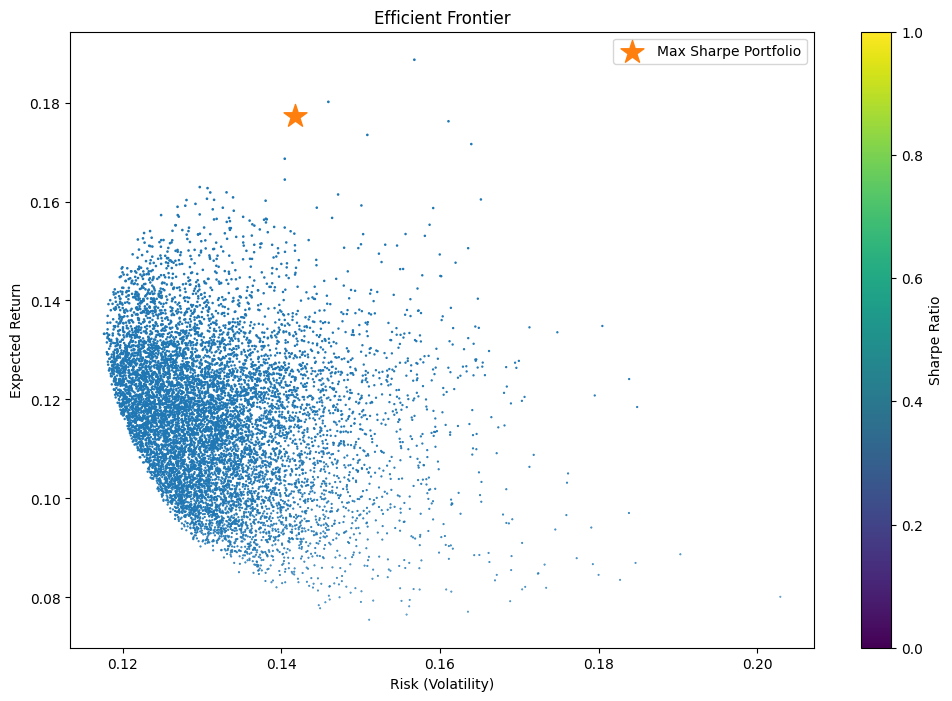

In [56]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
scatter=plt.scatter(portfolio_risks
,portfolio_returns,
portfolio_sharpes)
plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    best_risk,
    best_return,
    marker="*",
    s=300,
    label="Max Sharpe Portfolio"
)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier")
plt.legend()

plt.show()
